<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_2/blob/main/8_1_1_PRACTICE_Black_Friday_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning: Linear Regression

## Black Friday Sales Prediction:

We are going to use a dataset of product purchases during a Black Friday (in the US). The main idea is to be able to generate a predictor that allows us to predict the `purchase amount`.

In order to achieve a good predictor we must apply the different concepts that we have been learning:

* `Exploration`
* `Feature Engineering`
* `Modeling`
* `Evaluation`

The dataset here is a sample of the transactions made in a retail store. The store wants to know better the customer `purchase` behaviour against different products. The problem is a `regression problem` where we are trying to predict the dependent variable (the amount of purchase) with the help of the information contained in the other variables.

### You can try differents Scikit-Learn models from [Linear Models](https://scikit-learn.org/1.5/modules/linear_model.html)

Loaded file: BlackFriday.csv | shape: (537577, 12) | load time: 1.20s

--- head ---
 User_ID Product_ID Gender  Age  Occupation City_Category Stay_In_Current_City_Years  Marital_Status  Product_Category_1  Product_Category_2  Product_Category_3  Purchase
 1000001  P00069042      F 0-17          10             A                          2               0                   3                 NaN                 NaN      8370
 1000001  P00248942      F 0-17          10             A                          2               0                   1                 6.0                14.0     15200
 1000001  P00087842      F 0-17          10             A                          2               0                  12                 NaN                 NaN      1422
 1000001  P00085442      F 0-17          10             A                          2               0                  12                14.0                 NaN      1057
 1000002  P00285442      M  55+          16             C    

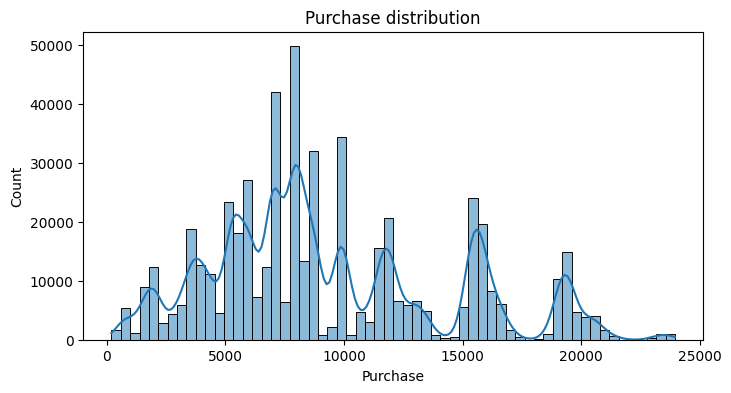


Final features count: 12

LinearRegression -> RMSE: 4619.48, R2: 0.1407
Approx CV RMSE (Ridge): 4613.77


In [3]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

csv_path = "BlackFriday.csv"
if not os.path.exists(csv_path):
    try:
        !gdown "1HZ_nk9Q0xp-qbAtXZvDxK5VNVfavt7ph" -O {csv_path}
    except Exception as e:
        print("gdown failed or not available. Make sure the CSV is in the environment:", e)

start = time.time()
data = pd.read_csv(csv_path)
print("Loaded file:", csv_path, "| shape:", data.shape, "| load time: %.2fs" % (time.time() - start))

print("\n--- head ---")
print(data.head(5).to_string(index=False))

print("\n--- info ---")
data.info()

print("\n--- numeric description ---")
print(data.describe().T)

print("\n--- missing values per column ---")
start = time.time()
print(data.isna().sum())
print("isna().sum() time: %.2fs" % (time.time() - start))

cat_cols = ["Gender", "Age", "City_Category", "Stay_In_Current_City_Years", "Marital_Status"]
for c in cat_cols:
    print(f"\n--- value counts: {c} ---")
    print(data[c].value_counts(dropna=False))

plt.figure(figsize=(8,4))
sns.histplot(data["Purchase"], bins=60, kde=True)
plt.title("Purchase distribution")
plt.xlabel("Purchase")
plt.show()

df = data.copy()

for col in ["Product_Category_2", "Product_Category_3"]:
    df[col + "_missing"] = df[col].isna().astype(int)
    df[col] = df[col].fillna(0)

age_map = {"0-17":0, "18-25":1, "26-35":2, "36-45":3, "46-50":4, "51-55":5, "55+":6}
df["Age_encoded"] = df["Age"].map(age_map)
df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].replace("4+", "4").astype(int)
df["Gender_enc"] = (df["Gender"] == "M").astype(int)

for c in ["Product_Category_1", "Product_Category_2", "Product_Category_3"]:
    df[c] = df[c].astype(int)

features = [
    "Gender_enc", "Age_encoded", "Stay_In_Current_City_Years",
    "Marital_Status", "Occupation", "City_Category",
    "Product_Category_1", "Product_Category_2", "Product_Category_3",
    "Product_Category_2_missing", "Product_Category_3_missing"
]

X = df[features].copy()
y = df["Purchase"].copy()

X = pd.get_dummies(X, columns=["City_Category"], drop_first=True)

print("\nFinal features count:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
numeric_cols = ["Age_encoded", "Stay_In_Current_City_Years", "Product_Category_1", "Product_Category_2", "Product_Category_3"]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"\nLinearRegression -> RMSE: {rmse_lr:.2f}, R2: {r2_lr:.4f}")

ridge = Ridge(random_state=42)
try:
    cv_scores = -cross_val_score(ridge, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
    cv_rmse = cv_scores.mean()
except Exception:
    cv_mse_scores = -cross_val_score(ridge, X, y, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rmse = np.sqrt(cv_mse_scores).mean()

print(f"Approx CV RMSE (Ridge): {cv_rmse:.2f}")